# Waypoint-Guided ECD Compilation of a Brachistochrone Trajectory

The quantum brachistochrone gives the *time-optimal* path from the vacuum to a GKP
logical state under a spectral-norm bound $\lVert H \rVert = \omega$: a geodesic in
projective Hilbert space, traversed at constant rate, arriving at
$T = \Omega_B / \omega$ where $\Omega_B = \arccos|\braket{\psi_i|\psi_f}|$ is the
Bures angle. That Hamiltonian is not implementable — it is a rank-2 operator built
from the target itself, not a drive on a cavity-transmon system. But the *path* it
traces is a legitimate object to compile against.

This notebook does that compilation at the **gate level**:

1. Sample the brachistochrone geodesic at $M+1$ points, giving $M$ intermediate
   waypoints $\ket{\psi_0} = \ket{0}, \ket{\psi_1}, \dots, \ket{\psi_M} \simeq \ket{\psi_f}$.
2. For each hop $\ket{\psi_{m}} \to \ket{\psi_{m+1}}$, optimize a short ECD +
   rotation circuit of depth $N_{\text{seg}}$ (Eickbusch et al., *Nat. Phys.* **18**,
   1464 (2022)), using the existing `gate_optimization` machinery.
3. Chain the segment circuits back to back and measure the fidelity actually
   achieved, carrying the residual $\ket{e}$ population honestly rather than
   assuming each segment ends with a perfectly disentangled qubit.

The question worth asking: at a **fixed total ECD budget** $N_{\text{tot}} = M
\cdot N_{\text{seg}}$, does breaking the problem into waypoint hops beat optimizing
one deep circuit end to end? There are two competing effects. Splitting convexifies
the landscape — each hop is a small-angle problem with a nearly-trivial solution and
a warm start available from the previous hop. But splitting also *constrains* the
path: the circuit is forced through intermediate states it need not visit, and the
geodesic of the brachistochrone Hamiltonian is not a geodesic of the sub-Finsler
metric induced by the ECD gate set. Nothing guarantees the time-optimal path is
also the gate-count-optimal one.

Everything is JAX (x64), gates are ideal unitaries, and the qubit is carried in the
$2\times 2$ block representation used throughout `gate_optimization`. Pulse-level
compilation is a follow-up, sketched at the end.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import time
from dataclasses import dataclass, replace

import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import jaxquantum as jqt
import matplotlib.pyplot as plt
import numpy as np

from gkp_optimal_control.brachistochrone import quantum_brachistochrone_hamiltonian
from gkp_optimal_control.gate_optimization import (
    GateBounds,
    OptimizerConfig,
    build_sequence,
    optimize_gate_sequence,
)
from gkp_optimal_control.plotting import plot_photon_number, plot_wigner, set_plot_style
from gkp_optimal_control.states import gkp_states
from gkp_optimal_control.utils import to_ket, to_qarray

set_plot_style()

print(f"JAX devices : {jax.devices()}")
print(f"backend     : {jax.default_backend()}")
print(f"x64 enabled : {jnp.zeros(1).dtype == jnp.float64}")

JAX devices : [CpuDevice(id=0)]
backend     : cpu
x64 enabled : True


## System and target

Square-lattice GKP code, $\alpha = \sqrt{\pi/2}$, $\beta = i\sqrt{\pi/2}$, envelope
$\Delta$. We work with raw `jnp` kets in the differentiable layer and cross into
`jaxquantum.Qarray` only for Wigner functions and plotting, via `to_ket` / `to_qarray`.

`disp_method="quadrature"` is used throughout: exactly unitary on the truncated space,
same accuracy as `expm`, roughly 4x faster, and its gradients flow through a diagonal
exponential instead of an `expm` Frechet derivative — which matters here because we run
many small optimizations rather than one big one.

In [2]:
n_fock = 60
gkp_delta = 0.35
gkp_cutoff = 8
gkp_alpha = jnp.sqrt(jnp.pi / 2)
gkp_beta = 1j * jnp.sqrt(jnp.pi / 2)

DISP_METHOD = "quadrature"
X_BOUND = Y_BOUND = 5.0

vac = jqt.basis(n_fock, 0)
gkp_0, gkp_1 = gkp_states(n_fock, gkp_alpha, gkp_beta, gkp_delta, gkp_cutoff)

psi_i = to_ket(vac)  # (n_fock,) raw ket
psi_f = to_ket(gkp_0)
target_label = "0_L"

n_bar = float(jnp.sum(jnp.arange(n_fock) * jnp.abs(psi_f) ** 2))
tail_pop = float(jnp.sum(jnp.abs(psi_f[-8:]) ** 2))

print(f"target        : |{target_label}>")
print(f"squeezing     : {-10 * np.log10(gkp_delta ** 2):.2f} dB")
print(f"nbar          : {n_bar:.3f}")
print(f"top-8 Fock    : {tail_pop:.2e}   (truncation headroom check)")
print(f"|<0|{target_label}>|      : {float(jnp.abs(jnp.vdot(psi_i, psi_f))):.6f}")

target        : |0_L>
squeezing     : 9.12 dB
nbar          : 4.327
top-8 Fock    : 2.43e-05   (truncation headroom check)
|<0|0_L>|      : 0.614545


## The geodesic and its waypoints

`quantum_brachistochrone_hamiltonian` returns a constant $H$ that acts only inside
$\mathrm{span}\{\ket{\psi_i}, \ket{\psi_f^\perp}\}$. Writing $\ket{\psi_f^\perp}$ for
the normalized orthogonal component of the target and
$\braket{\psi_i|\psi_f} = \cos\Omega_B\, e^{i\phi}$, that Hamiltonian is
$\omega(\sin\phi\,\sigma_x + \cos\phi\,\sigma_y)$ in the $\{\ket{\psi_i},
\ket{\psi_f^\perp}\}$ basis — a unit vector on the Bloch equator, so
$\exp(-iHt) = \cos\omega t - i \sin\omega t \,(\hat n \cdot \vec\sigma)$ and the
trajectory has the closed form

$$\ket{\psi(s)} = \cos(\Omega_B s)\ket{\psi_i}
  + \sin(\Omega_B s)\, e^{-i\phi} \ket{\psi_f^\perp},
  \qquad s = t/T \in [0, 1],$$

with $\ket{\psi(1)} = e^{-i\phi}\ket{\psi_f}$. We use the closed form to place
waypoints (exact, no ODE solve, differentiable) and check it against
`expm(-i H t)` built from the module's own Hamiltonian.

In [3]:
def geodesic_waypoints(psi_init, psi_targ, n_segments):
    r"""Sample the brachistochrone geodesic at ``n_segments + 1`` equally spaced points.

    Parameters
    ----------
    psi_init, psi_targ : jnp.ndarray
        Normalized 1D kets, shape ``(n_fock,)``. Must not be orthogonal.
    n_segments : int
        Number of hops. Returns ``n_segments + 1`` waypoints, the first equal to
        ``psi_init`` and the last equal to ``psi_targ`` up to a global phase.

    Returns
    -------
    waypoints : jnp.ndarray
        Shape ``(n_segments + 1, n_fock)``.
    theta_b : float
        Bures angle between the endpoints, which is also the total arc length.
    """
    psi_init = psi_init / jnp.linalg.norm(psi_init)
    psi_targ = psi_targ / jnp.linalg.norm(psi_targ)

    overlap = jnp.vdot(psi_init, psi_targ)  # <psi_i | psi_f>
    perp = psi_targ - overlap * psi_init
    perp = perp / jnp.linalg.norm(perp)

    phi = jnp.angle(overlap)
    theta_b = jnp.arccos(jnp.clip(jnp.abs(overlap), 0.0, 1.0))

    s = jnp.linspace(0.0, 1.0, n_segments + 1)
    waypoints = (
        jnp.cos(theta_b * s)[:, None] * psi_init[None, :]
        + (jnp.sin(theta_b * s) * jnp.exp(-1j * phi))[:, None] * perp[None, :]
    )
    return waypoints, float(theta_b)


def bures_angles(waypoints):
    """Per-hop Bures angles ``arccos|<psi_m|psi_{m+1}>|``, shape ``(M,)``."""
    ov = jnp.sum(jnp.conj(waypoints[:-1]) * waypoints[1:], axis=-1)
    return jnp.arccos(jnp.clip(jnp.abs(ov), 0.0, 1.0))

In [5]:
# Cross-check the closed form against expm of the module's Hamiltonian.
n_check = 6
wp_check, theta_b = geodesic_waypoints(psi_i, psi_f, n_check)

h_out, min_time = quantum_brachistochrone_hamiltonian(psi_i, psi_f, energy_bound=1.0)
h = jnp.asarray(h_out.data if isinstance(h_out, jqt.Qarray) else h_out)
h = h.reshape(n_fock, n_fock)
h_norm = float(jnp.max(jnp.linalg.svd(h, compute_uv=False)))

tlist = jnp.linspace(0.0, float(min_time), n_check + 1)
wp_expm = jnp.stack([jax.scipy.linalg.expm(-1j * h * t) @ psi_i for t in tlist])

print(f"theta_B              : {theta_b:.6f} rad   ({theta_b / (jnp.pi / 2):.4f} x pi/2)")
print(f"T = theta_B / ||H||  : {float(min_time):.6f}")
print(f"||H||                : {h_norm:.6f}")
print(f"H hermiticity        : {float(jnp.abs(h - h.conj().T).max()):.2e}")
print(f"closed form vs expm  : {float(jnp.abs(wp_check - wp_expm).max()):.2e}")
print(f"|<psi_f | psi(1)>|   : {float(jnp.abs(jnp.vdot(psi_f, wp_check[-1]))):.12f}")

theta_B              : 0.908987 rad   (0.5787 x pi/2)
T = theta_B / ||H||  : 0.908987
||H||                : 1.000000
H hermiticity        : 0.00e+00
closed form vs expm  : 3.33e-16
|<psi_f | psi(1)>|   : 1.000000000000


### Equal time splits are equal arc-length splits

Because $H$ is constant with unit spectral norm on a 2D subspace, the state sweeps a
great circle at constant angular rate. So uniform sampling in $t$ gives uniform
sampling in Bures angle: every hop subtends exactly $\Omega_B / M$, and the hop angles
sum to $\Omega_B$ (the geodesic saturates the triangle inequality). Each hop therefore
costs the same *time* under the Mandelstam-Tamm bound. Whether each hop costs the same
number of *ECDs* is the empirical question below.

This is a useful invariant to check, and a reminder of the SNAP-trajectory lesson: a
uniform schedule in time is only a uniform schedule in the thing you care about if the
dynamics move at constant speed. Here they do, by construction.

In [6]:
for m in (1, 2, 3, 6, 12):
    wp_m, th = geodesic_waypoints(psi_i, psi_f, m)
    ang = np.asarray(bures_angles(wp_m))
    print(
        f"M = {m:2d}   theta_seg in [{ang.min():.6f}, {ang.max():.6f}]   "
        f"theta_B/M = {th / m:.6f}   sum = {ang.sum():.6f}  (theta_B = {th:.6f})"
    )

M =  1   theta_seg in [0.908987, 0.908987]   theta_B/M = 0.908987   sum = 0.908987  (theta_B = 0.908987)
M =  2   theta_seg in [0.454493, 0.454493]   theta_B/M = 0.454493   sum = 0.908987  (theta_B = 0.908987)
M =  3   theta_seg in [0.302996, 0.302996]   theta_B/M = 0.302996   sum = 0.908987  (theta_B = 0.908987)
M =  6   theta_seg in [0.151498, 0.151498]   theta_B/M = 0.151498   sum = 0.908987  (theta_B = 0.908987)
M = 12   theta_seg in [0.075749, 0.075749]   theta_B/M = 0.075749   sum = 0.908987  (theta_B = 0.908987)


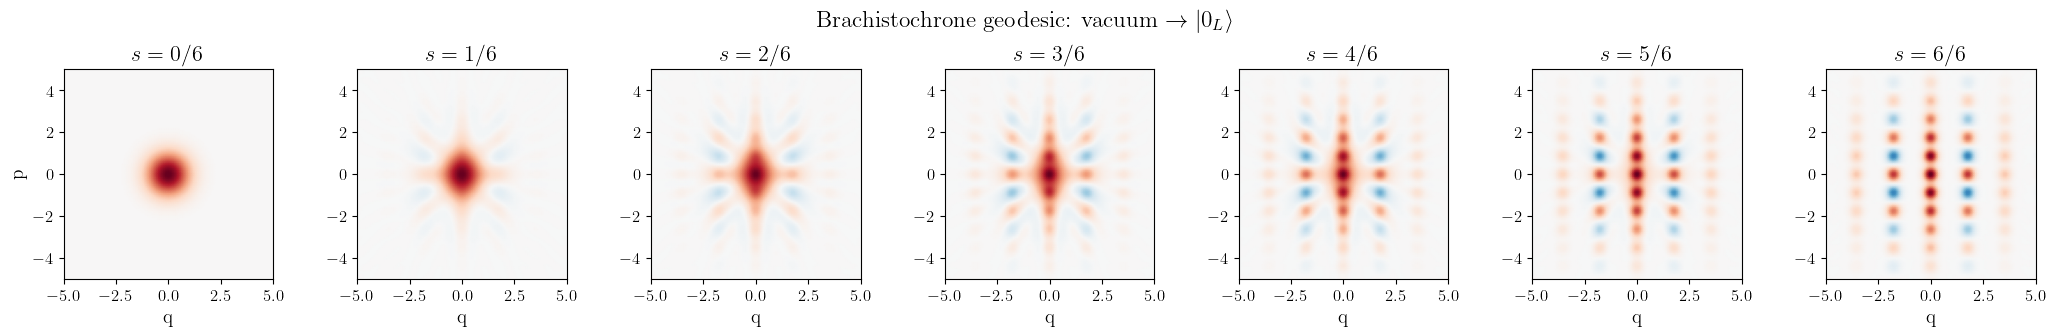

In [7]:
n_preview = 6
wp_preview, _ = geodesic_waypoints(psi_i, psi_f, n_preview)

fig, axes = plt.subplots(1, n_preview + 1, figsize=(3.0 * (n_preview + 1), 3.2))
for k, ax in enumerate(axes):
    plot_wigner(
        to_qarray(wp_preview[k]),
        x_bound=X_BOUND,
        y_bound=Y_BOUND,
        ax=ax,
        title=rf"$s = {k}/{n_preview}$",
        grid_points=120,
        add_colorbar=False,
    )
    if k:
        ax.set_ylabel("")
fig.suptitle(rf"Brachistochrone geodesic: vacuum $\to \ket{{{target_label}}}$")
fig.tight_layout()
plt.show()

## Segment compilation machinery

Three helpers.

**`make_init_batch`** builds the multi-start batch by hand so that slot 0 can hold a
warm start — the previous hop's solution. Consecutive hops along a geodesic are similar
problems, so this matters: it converts the multi-start from a blind search into a
search around a known-good point. The random slots use `init_disp_scale` tied to the
hop's Bures angle, because a small-angle hop needs small $\beta$ and initializing with
$|\beta| \sim 1$ throws the state out of the truncation for free.

**`chain_segments`** runs the segment circuits back to back on the joint $(2, n_{\text{fock}})$
block state. It does *not* reset the qubit between segments: whatever $\ket{e}$
amplitude segment $m$ leaves behind is propagated into segment $m+1$. With
`reset_qubit=True` it instead projects onto $\ket{g}$ and renormalizes, which
corresponds to heralding on a mid-circuit measurement, and returns the cumulative
success probability. Reporting both keeps the accounting honest — the unheralded
number is what an open-loop circuit delivers.

**`compile_geodesic`** drives the whole thing. Two modes:

- `mode="ideal"` — every hop is optimized from its exact waypoint. Segments are then
  independent, and errors compound.
- `mode="greedy"` — hop $m+1$ is optimized starting from the state hop $m$ *actually*
  produced (its $\ket{g}$ component, renormalized), so each hop re-aims at the
  geodesic instead of inheriting the previous error. Almost free, and strictly better.

A phase subtlety worth stating: each segment's objective is $|\braket{\psi_{m+1}|\psi}|^2$,
so the optimizer is free to land on $e^{i\chi}\ket{\psi_{m+1}}$. Because the circuits
are linear, a phase on a segment's input factors straight out of its output, so these
per-hop phases cannot accumulate into an error. Verified numerically two cells down.

In [8]:
ECD_KW = dict(disp_method=DISP_METHOD, echoed=True, qubit_target="ground")


def _n_gates_from_params(flat):
    """Recover the ECD count from a flat parameter vector (n_params = 4N + 2)."""
    n_params = int(np.size(flat))
    n_gates, rem = divmod(n_params - 2, 4)
    if rem != 0 or n_gates < 1:
        raise ValueError(f"{n_params} is not a valid ECD parameter count (expected 4N+2)")
    return n_gates


def _ecd_sequence(n_gates, n_fock, n_leak=0, init_disp_scale=1.0):
    return build_sequence(
        "ecd",
        n_gates,
        n_fock,
        n_leak=n_leak,
        init_disp_scale=init_disp_scale,
        **ECD_KW,
    )


def make_init_batch(n_gates, n_fock, n_seeds, *, scale, seed, warm=None):
    """Multi-start batch ``(n_seeds, n_params)``, optionally warm-started in slot 0."""
    seq = _ecd_sequence(n_gates, n_fock, init_disp_scale=scale)
    n_rand = n_seeds - (1 if warm is not None else 0)
    batch = None
    if n_rand > 0:
        keys = jax.random.split(jax.random.PRNGKey(seed), n_rand)
        batch = jnp.stack([seq.init(keys[i]) for i in range(n_rand)])
    if warm is None:
        return batch
    warm = jnp.asarray(warm, dtype=jnp.result_type(float))[None, :]
    return warm if batch is None else jnp.concatenate([warm, batch], axis=0)

In [9]:
def chain_segments(seg_params, psi_start, n_fock, *, reset_qubit=False):
    """Run segment circuits back to back on one cavity state.

    Parameters
    ----------
    seg_params : sequence of array_like
        Flat ECD parameter vectors, one per segment, applied in order. Depths may
        differ; each is inferred from its length.
    psi_start : array_like
        Cavity ket ``(n_fock,)``. The qubit starts in ``|g>``.
    reset_qubit : bool
        If True, project onto ``|g>`` and renormalize after every segment
        (mid-circuit heralding). If False, carry the ``|e>`` amplitude through.

    Returns
    -------
    states : jnp.ndarray
        Block states after each segment, ``(M + 1, 2, n_fock)``, index 0 being the
        (lifted) input.
    e_population : ndarray
        ``|e>`` population at the end of each segment, before any reset.
    herald_probability : float
        Cumulative probability of measuring ``|g>`` at every reset; 1.0 when
        ``reset_qubit=False``.
    """
    ket = jnp.asarray(psi_start).reshape(-1)
    ket = ket / jnp.linalg.norm(ket)
    psi = jnp.stack([ket[None, :], jnp.zeros_like(ket)[None, :]], axis=1)  # (1, 2, d)

    states = [psi[0]]
    e_population = []
    herald = 1.0

    for flat in seg_params:
        seq = _ecd_sequence(_n_gates_from_params(flat), n_fock)
        psi, _, _ = seq.propagate(jnp.asarray(flat, dtype=jnp.result_type(float)), psi)
        e_population.append(float(jnp.sum(jnp.abs(psi[0, 1, :]) ** 2)))
        if reset_qubit:
            psi_g = psi[:, 0, :]
            p_g = jnp.sum(jnp.abs(psi_g) ** 2)
            herald *= float(p_g)
            psi = jnp.stack([psi_g / jnp.sqrt(p_g), jnp.zeros_like(psi_g)], axis=1)
        states.append(psi[0])

    return jnp.stack(states), np.asarray(e_population), herald


def cavity_fidelity(block_state, target):
    """|<target | psi_g>|^2 for a block state of shape ``(2, n_fock)``."""
    return float(jnp.abs(jnp.sum(jnp.conj(jnp.asarray(target)) * block_state[0])) ** 2)

In [10]:
# Sanity checks on the chaining helper, with random (unoptimized) parameters:
# the chain must be norm preserving, and a global phase on the input must pass
# straight through to the output.
rng = np.random.default_rng(0)
_flats = [rng.normal(size=4 * 3 + 2) for _ in range(3)]

_j1, _e1, _h1 = chain_segments(_flats, psi_i, n_fock)
_j2, _, _ = chain_segments(_flats, jnp.exp(1j * 0.7) * psi_i, n_fock)
_j3, _, _h3 = chain_segments(_flats, psi_i, n_fock, reset_qubit=True)

print(f"norm drift          : {abs(float(jnp.linalg.norm(_j1[-1])) - 1.0):.2e}")
print(f"phase passthrough   : {float(jnp.abs(_j2[-1] - jnp.exp(1j * 0.7) * _j1[-1]).max()):.2e}")
print(f"|e> pop per segment : {np.array2string(_e1, precision=3)}")
print(f"herald prob (reset) : {_h3:.4f}   (no reset: {_h1:.1f})")

norm drift          : 5.55e-15
phase passthrough   : 5.55e-16
|e> pop per segment : [0.653 0.597 0.463]
herald prob (reset) : 0.0606   (no reset: 1.0)


In [11]:
@dataclass
class WaypointRun:
    """Outcome of compiling one brachistochrone geodesic into M ECD segments."""

    n_segments: int
    n_gates: int
    mode: str
    theta_b: float
    bures: np.ndarray
    waypoints: np.ndarray
    results: list
    segment_fidelity: np.ndarray
    cumulative_fidelity: np.ndarray
    composed_fidelity: float
    heralded_fidelity: float
    herald_probability: float
    e_population: np.ndarray
    joint_states: np.ndarray
    peak_beta: float
    wall_time: float

    @property
    def total_ecds(self):
        return self.n_segments * self.n_gates

    def summary(self):
        lines = [
            f"segments        : {self.n_segments} x {self.n_gates} ECD "
            f"= {self.total_ecds} total",
            f"mode            : {self.mode}",
            f"theta_B         : {self.theta_b:.4f}   per hop {self.theta_b / self.n_segments:.4f}",
            f"per-hop 1-F     : {self.worst_hop_infidelity:.3e} (worst), "
            f"{np.median(1 - self.segment_fidelity):.3e} (median)",
            f"composed F      : {self.composed_fidelity:.6f}  "
            f"(1-F = {1 - self.composed_fidelity:.3e})",
            f"heralded F      : {self.heralded_fidelity:.6f}  "
            f"(1-F = {1 - self.heralded_fidelity:.3e}, p = {self.herald_probability:.4f})",
            f"final |e> pop   : {self.e_population[-1]:.3e}",
            f"peak |beta|     : {self.peak_beta:.3f}",
            f"wall time       : {self.wall_time:.1f}s",
        ]
        return "\n".join(lines)

    @property
    def worst_hop_infidelity(self):
        return float(np.max(1 - self.segment_fidelity))

In [12]:
def compile_geodesic(
    psi_init,
    psi_targ,
    n_segments,
    n_gates,
    *,
    mode="greedy",
    warm_start=True,
    optimizer=None,
    bounds=None,
    loss_type="log_infidelity",
    verbose=True,
):
    """Split the brachistochrone geodesic into hops and fit an ECD circuit to each.

    Parameters
    ----------
    n_segments, n_gates : int
        Number of hops, and ECDs per hop. Total circuit depth is their product.
    mode : {"greedy", "ideal"}
        Whether each hop starts from the previously achieved state or from the
        exact waypoint.
    warm_start : bool
        Seed each hop's multi-start with the previous hop's solution.
    """
    if mode not in ("greedy", "ideal"):
        raise ValueError(f"unknown mode {mode!r}; expected 'greedy' or 'ideal'")

    optimizer = optimizer or OptimizerConfig(n_seeds=8, n_adam_iters=1200)
    bounds = bounds or GateBounds(max_disp=3.0, n_leak=8)
    n_fock_local = int(jnp.asarray(psi_init).shape[-1])

    waypoints, theta_b = geodesic_waypoints(psi_init, psi_targ, n_segments)
    bures = np.asarray(bures_angles(waypoints))

    t0 = time.time()
    results, seg_fid = [], []
    start, warm = waypoints[0], None

    for m in range(n_segments):
        # Small hops need small displacements; scaling the initialization with the
        # hop's arc length keeps the random seeds out of the truncation boundary.
        scale = float(np.clip(2.0 * bures[m], 0.25, 2.0))
        params0 = make_init_batch(
            n_gates,
            n_fock_local,
            optimizer.n_seeds,
            scale=scale,
            seed=optimizer.seed + 1000 * m + 1,
            warm=warm if warm_start else None,
        )
        res = optimize_gate_sequence(
            "ecd",
            n_gates,
            start,
            waypoints[m + 1],
            n_fock=n_fock_local,
            loss_type=loss_type,
            bounds=bounds,
            optimizer=replace(optimizer, init_disp_scale=scale),
            params0=params0,
            verbose=False,
            **ECD_KW,
        )
        results.append(res)
        seg_fid.append(res.fidelity)
        warm = jnp.asarray(res.flat_params)

        if mode == "greedy":
            psi_g = jnp.asarray(res.final_states)[0, 0, :]
            start = psi_g / jnp.linalg.norm(psi_g)
        else:
            start = waypoints[m + 1]

        if verbose:
            print(
                f"  hop {m + 1:2d}/{n_segments}  theta = {bures[m]:.4f}  "
                f"F = {res.fidelity:.6f}  1-F = {1 - res.fidelity:.2e}  "
                f"peak|beta| = {res.params['disp_magnitudes'].max():.2f}  "
                f"leak = {res.leakage:.1e}"
            )

    seg_params = [r.flat_params for r in results]
    joint, e_pop, _ = chain_segments(seg_params, waypoints[0], n_fock_local)
    joint_h, _, herald = chain_segments(
        seg_params, waypoints[0], n_fock_local, reset_qubit=True
    )

    cumulative = np.array(
        [cavity_fidelity(joint[m + 1], waypoints[m + 1]) for m in range(n_segments)]
    )
    composed = cavity_fidelity(joint[-1], psi_targ)
    heralded = cavity_fidelity(joint_h[-1], psi_targ)
    peak_beta = float(max(np.max(r.params["disp_magnitudes"]) for r in results))

    run = WaypointRun(
        n_segments=n_segments,
        n_gates=n_gates,
        mode=mode,
        theta_b=theta_b,
        bures=bures,
        waypoints=np.asarray(waypoints),
        results=results,
        segment_fidelity=np.asarray(seg_fid),
        cumulative_fidelity=cumulative,
        composed_fidelity=composed,
        heralded_fidelity=heralded,
        herald_probability=herald,
        e_population=e_pop,
        joint_states=np.asarray(joint),
        peak_beta=peak_beta,
        wall_time=time.time() - t0,
    )
    if verbose:
        print("-" * 62)
        print(run.summary())
    return run

## One run in detail

Six hops, two ECDs each: a 12-ECD circuit in total. Watch two things in the output.
First, whether the per-hop infidelities are uniform — they should be, since the hops
are congruent in arc length, and a strong non-uniformity means the ECD gate set finds
some stretches of the geodesic harder than others (which is exactly the sub-Finsler
anisotropy the geodesic knows nothing about). Second, the gap between the per-hop
fidelities and the composed fidelity, which is the price of error accumulation plus
residual qubit entanglement.

In [13]:
N_SEGMENTS = 6
N_GATES_PER_SEGMENT = 2

OPT = OptimizerConfig(
    n_seeds=8,
    n_adam_iters=1200,
    peak_lr=0.03,
    polish=True,
    polish_maxiter=500,
    seed=0,
)
BOUNDS = GateBounds(max_disp=3.0, max_disp_weight=1.0, n_leak=8, leakage_weight=1.0)

run = compile_geodesic(
    psi_i,
    psi_f,
    N_SEGMENTS,
    N_GATES_PER_SEGMENT,
    mode="greedy",
    optimizer=OPT,
    bounds=BOUNDS,
)

  hop  1/6  theta = 0.1515  F = 0.980931  1-F = 1.91e-02  peak|beta| = 1.11  leak = 3.7e-32
  hop  2/6  theta = 0.1515  F = 0.933512  1-F = 6.65e-02  peak|beta| = 1.15  leak = 7.3e-32
  hop  3/6  theta = 0.1515  F = 0.866304  1-F = 1.34e-01  peak|beta| = 1.33  leak = 5.6e-26
  hop  4/6  theta = 0.1515  F = 0.785241  1-F = 2.15e-01  peak|beta| = 2.54  leak = 1.2e-11
  hop  5/6  theta = 0.1515  F = 0.691834  1-F = 3.08e-01  peak|beta| = 1.40  leak = 8.4e-10
  hop  6/6  theta = 0.1515  F = 0.625627  1-F = 3.74e-01  peak|beta| = 2.26  leak = 6.1e-08
--------------------------------------------------------------
segments        : 6 x 2 ECD = 12 total
mode            : greedy
theta_B         : 0.9090   per hop 0.1515
per-hop 1-F     : 3.744e-01 (worst), 1.742e-01 (median)
composed F      : 0.619164  (1-F = 3.808e-01)
heralded F      : 0.641805  (1-F = 3.582e-01, p = 0.9415)
final |e> pop   : 3.081e-02
peak |beta|     : 2.536
wall time       : 39.9s


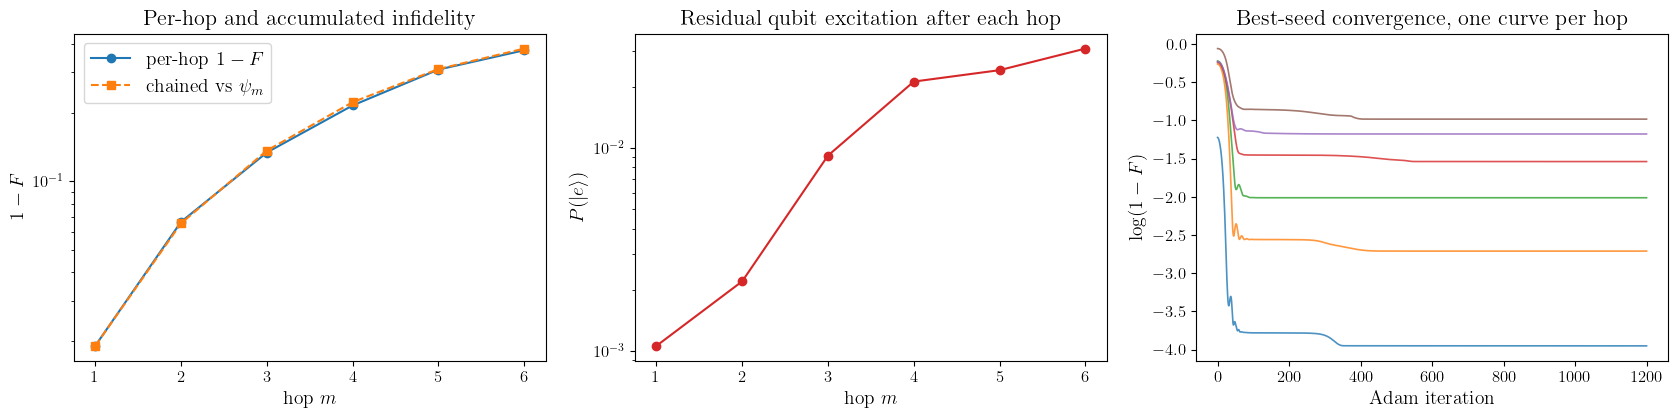

In [14]:
fig, (ax_f, ax_c, ax_h) = plt.subplots(1, 3, figsize=(17, 4.4))

hops = np.arange(1, run.n_segments + 1)

ax_f.semilogy(hops, 1 - run.segment_fidelity, "o-", label="per-hop $1-F$")
ax_f.semilogy(hops, 1 - run.cumulative_fidelity, "s--", label=r"chained vs $\psi_m$")
ax_f.set_xlabel("hop $m$")
ax_f.set_ylabel(r"$1 - F$")
ax_f.set_title("Per-hop and accumulated infidelity")
ax_f.legend()

ax_c.semilogy(hops, run.e_population, "o-", color="C3")
ax_c.set_xlabel("hop $m$")
ax_c.set_ylabel(r"$P(\ket{e})$")
ax_c.set_title("Residual qubit excitation after each hop")

for r in run.results:
    ax_h.plot(r.adam_history[r.best_seed], alpha=0.8, lw=1.2)
ax_h.set_xlabel("Adam iteration")
ax_h.set_ylabel(r"$\log(1-F)$")
ax_h.set_title("Best-seed convergence, one curve per hop")

fig.tight_layout()
plt.show()

In [15]:
# Per-hop parameter inventory: the displacements the compiler actually asked for.
# Seed spread is the diagnostic for whether the warm start is doing any work -- a
# wide spread with the best seed near the top means the landscape is still rough.
print(f"{'hop':>4} {'theta':>8} {'1-F':>10} {'seed spread':>22}   |beta| per ECD")
for m, r in enumerate(run.results):
    mags = " ".join(f"{v:.3f}" for v in r.params["disp_magnitudes"])
    spread = f"{r.per_seed_fidelity.min():.4f} .. {r.per_seed_fidelity.max():.4f}"
    print(f"{m + 1:>4} {run.bures[m]:8.4f} {1 - r.fidelity:10.2e} {spread:>22}   {mags}")

 hop    theta        1-F            seed spread   |beta| per ECD
   1   0.1515   1.91e-02       0.9772 .. 0.9808   1.112 1.102
   2   0.1515   6.65e-02       0.9227 .. 0.9335   1.148 1.101
   3   0.1515   1.34e-01       0.8503 .. 0.8663   1.328 1.235
   4   0.1515   2.15e-01       0.7662 .. 0.7852   2.536 2.479
   5   0.1515   3.08e-01       0.6744 .. 0.6918   1.401 1.233
   6   0.1515   3.74e-01       0.5739 .. 0.6256   2.262 0.363


## Sweep: fixed total ECD budget, varying waypoint count

Now the comparison that matters. Hold the total ECD count fixed at $N_{\text{tot}}$ and
vary how it is partitioned: $M$ hops of $N_{\text{tot}}/M$ ECDs each. The $M = 1$ entry
is the monolithic problem — one hop from vacuum straight to the target, no waypoints —
so the baseline is inside the sweep rather than bolted on beside it.

The Adam budget per hop is held fixed, which means the total optimizer work grows
linearly in $M$. That favors large $M$ on wall clock, so the honest read of the plot is
infidelity against $M$ *and* against wall time, both of which are reported.

In [16]:
TOTAL_ECDS = 12
SEGMENT_COUNTS = [1, 2, 3, 4, 6, 12]  # divisors of TOTAL_ECDS

sweep = {}
for m in SEGMENT_COUNTS:
    n_g = TOTAL_ECDS // m
    print(f"\n=== M = {m} hops x {n_g} ECD = {TOTAL_ECDS} total " + "=" * 20)
    sweep[m] = compile_geodesic(
        psi_i,
        psi_f,
        m,
        n_g,
        mode="greedy",
        optimizer=OPT,
        bounds=BOUNDS,
        verbose=True,
    )


=== M = 1 hops x 12 ECD = 12 total ====================
  hop  1/1  theta = 0.9090  F = 0.993944  1-F = 6.06e-03  peak|beta| = 2.85  leak = 1.9e-04
--------------------------------------------------------------
segments        : 1 x 12 ECD = 12 total
mode            : greedy
theta_B         : 0.9090   per hop 0.9090
per-hop 1-F     : 6.056e-03 (worst), 6.056e-03 (median)
composed F      : 0.993944  (1-F = 6.056e-03)
heralded F      : 0.996301  (1-F = 3.699e-03, p = 0.9976)
final |e> pop   : 2.366e-03
peak |beta|     : 2.852
wall time       : 35.2s

=== M = 2 hops x 6 ECD = 12 total ====================
  hop  1/2  theta = 0.4545  F = 0.966302  1-F = 3.37e-02  peak|beta| = 2.40  leak = 3.4e-24
  hop  2/2  theta = 0.4545  F = 0.963202  1-F = 3.68e-02  peak|beta| = 2.73  leak = 1.5e-06
--------------------------------------------------------------
segments        : 2 x 6 ECD = 12 total
mode            : greedy
theta_B         : 0.9090   per hop 0.4545
per-hop 1-F     : 3.680e-02 (worst),

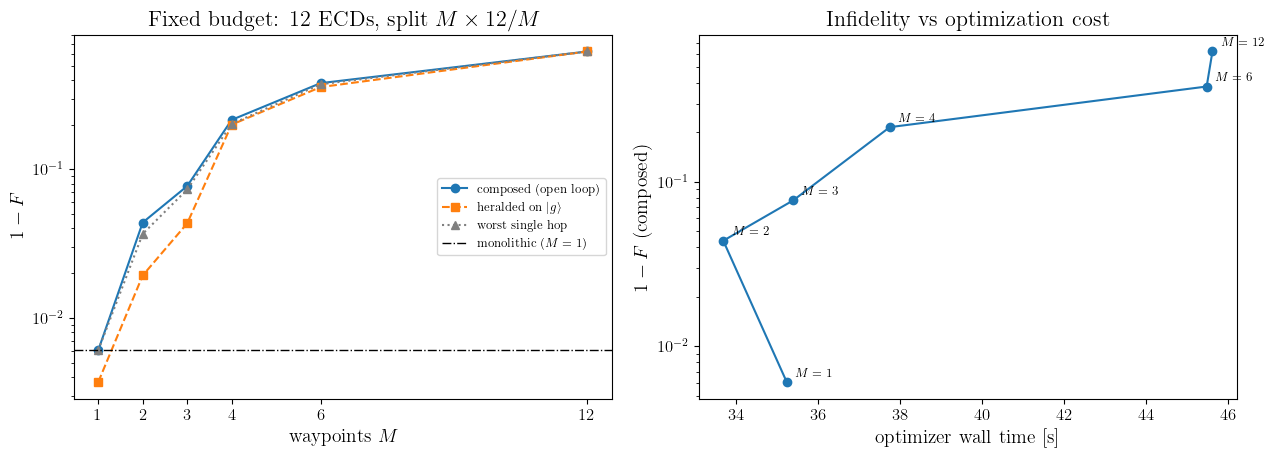

  M  N/seg   composed 1-F   heralded 1-F      p_g   peak|b|     time
  1     12      6.056e-03      3.699e-03   0.9976     2.852    35.2s
  2      6      4.389e-02      1.932e-02   0.9714     2.727    33.7s
  3      4      7.722e-02      4.331e-02   0.9698     2.811    35.4s
  4      3      2.154e-01      2.001e-01   0.9713     2.539    37.7s
  6      2      3.808e-01      3.582e-01   0.9415     2.536    45.5s
 12      1      6.223e-01      6.223e-01   1.0000     0.000    45.6s


In [17]:
ms = np.array(sorted(sweep))
composed = np.array([1 - sweep[m].composed_fidelity for m in ms])
heralded = np.array([1 - sweep[m].heralded_fidelity for m in ms])
worst_hop = np.array([sweep[m].worst_hop_infidelity for m in ms])
times = np.array([sweep[m].wall_time for m in ms])
peaks = np.array([sweep[m].peak_beta for m in ms])

fig, (ax_m, ax_t) = plt.subplots(1, 2, figsize=(13, 4.8))

ax_m.semilogy(ms, composed, "o-", label="composed (open loop)")
ax_m.semilogy(ms, heralded, "s--", label=r"heralded on $\ket{g}$")
ax_m.semilogy(ms, worst_hop, "^:", color="gray", label="worst single hop")
ax_m.axhline(composed[0], color="k", ls="-.", lw=1, label=r"monolithic ($M=1$)")
ax_m.set_xlabel("waypoints $M$")
ax_m.set_ylabel(r"$1 - F$")
ax_m.set_title(rf"Fixed budget: {TOTAL_ECDS} ECDs, split $M \times {{{TOTAL_ECDS}}}/M$")
ax_m.set_xticks(ms)
ax_m.legend(fontsize=9)

ax_t.semilogy(times, composed, "o-")
for m, t, c in zip(ms, times, composed):
    ax_t.annotate(f"$M={m}$", (t, c), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax_t.set_xlabel("optimizer wall time [s]")
ax_t.set_ylabel(r"$1 - F$ (composed)")
ax_t.set_title("Infidelity vs optimization cost")

fig.tight_layout()
plt.show()

print(f"{'M':>3} {'N/seg':>6} {'composed 1-F':>14} {'heralded 1-F':>14} {'p_g':>8} {'peak|b|':>9} {'time':>8}")
for m in ms:
    r = sweep[m]
    print(
        f"{m:>3} {r.n_gates:>6} {1 - r.composed_fidelity:>14.3e} "
        f"{1 - r.heralded_fidelity:>14.3e} {r.herald_probability:>8.4f} "
        f"{r.peak_beta:>9.3f} {r.wall_time:>7.1f}s"
    )

## Hop difficulty versus arc length

Pooling every hop from every run gives an empirical cost curve for the ECD gate set:
how much infidelity is left after $N_{\text{seg}}$ ECDs, as a function of the Bures
angle the hop has to cover. If the ECD set were isotropic and the brachistochrone path
were also its geodesic, these points would collapse onto one curve per depth. Scatter
at fixed $(\theta, N_{\text{seg}})$ is the signature of anisotropy — direction in
phase space mattering, not just distance.

This is the gate-level version of the arc-length diagnostic: summing the realized hop
angles and comparing against $\Omega_B$ tells you how much longer the compiled path is
than the Mandelstam-Tamm geodesic it was fitted to.

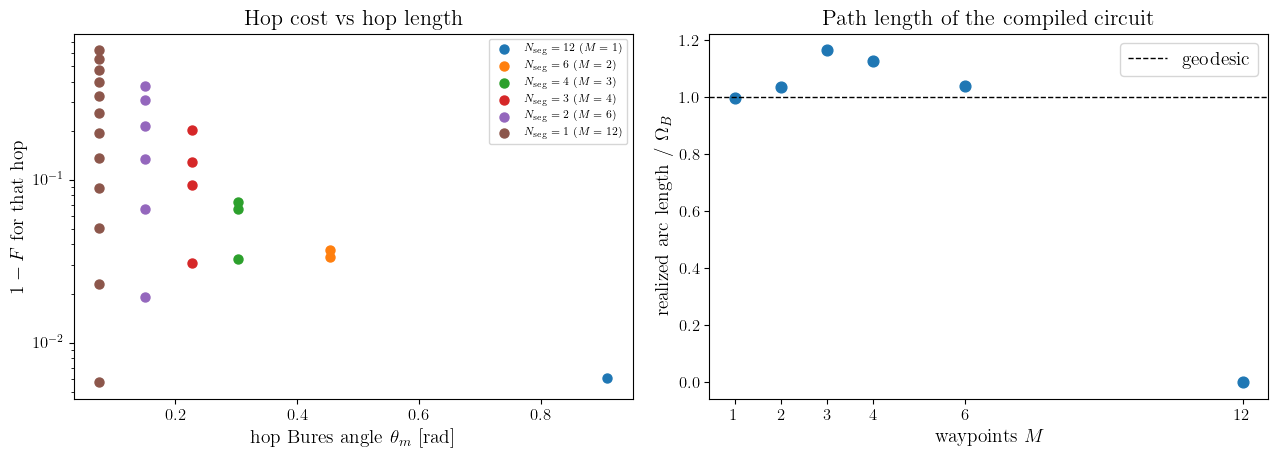

In [18]:
fig, (ax_s, ax_l) = plt.subplots(1, 2, figsize=(13, 4.8))

for m in ms:
    r = sweep[m]
    ax_s.scatter(
        r.bures,
        1 - r.segment_fidelity,
        s=42,
        label=rf"$N_{{\rm seg}} = {r.n_gates}$ ($M={m}$)",
    )
ax_s.set_yscale("log")
ax_s.set_xlabel(r"hop Bures angle $\theta_m$ [rad]")
ax_s.set_ylabel(r"$1 - F$ for that hop")
ax_s.set_title("Hop cost vs hop length")
ax_s.legend(fontsize=8)

# Realized arc length of the compiled path vs the geodesic it was fitted to.
for m in ms:
    r = sweep[m]
    states = r.joint_states[:, 0, :]  # |g> component along the chain
    states = states / np.linalg.norm(states, axis=-1, keepdims=True)
    ov = np.abs(np.sum(np.conj(states[:-1]) * states[1:], axis=-1))
    realized = float(np.sum(np.arccos(np.clip(ov, 0.0, 1.0))))
    ax_l.scatter(m, realized / r.theta_b, s=60, color="C0")
ax_l.axhline(1.0, color="k", ls="--", lw=1, label="geodesic")
ax_l.set_xlabel("waypoints $M$")
ax_l.set_ylabel(r"realized arc length / $\Omega_B$")
ax_l.set_title("Path length of the compiled circuit")
ax_l.set_xticks(ms)
ax_l.legend()

fig.tight_layout()
plt.show()

## Greedy versus ideal re-targeting

`mode="ideal"` optimizes every hop from its exact waypoint, so the segments never see
each other's errors; `mode="greedy"` re-aims each hop from the state actually produced.
The two give the same per-hop numbers in isolation but different composed fidelities,
and the gap is a direct measure of how much error the naive decomposition accumulates.

In [19]:
run_ideal = compile_geodesic(
    psi_i,
    psi_f,
    N_SEGMENTS,
    N_GATES_PER_SEGMENT,
    mode="ideal",
    optimizer=OPT,
    bounds=BOUNDS,
    verbose=False,
)

for tag, r in (("greedy", run), ("ideal", run_ideal)):
    print(
        f"{tag:>7}: median hop 1-F = {np.median(1 - r.segment_fidelity):.3e}   "
        f"composed 1-F = {1 - r.composed_fidelity:.3e}   "
        f"heralded 1-F = {1 - r.heralded_fidelity:.3e}"
    )

 greedy: median hop 1-F = 1.742e-01   composed 1-F = 3.808e-01   heralded 1-F = 3.582e-01
  ideal: median hop 1-F = 2.022e-02   composed 1-F = 5.240e-01   heralded 1-F = 5.227e-01


## Phase space: where the compiled circuit actually goes

Top row: the geodesic waypoints. Bottom row: the state the chained circuit actually
holds at the same point, with the qubit traced out — a density matrix, since the
residual $\ket{e}$ amplitude means the cavity state is genuinely mixed. That partial
trace is the reason `to_qarray` refuses a raw $(2, n_{\text{fock}})$ block: flattening
it would silently produce a meaningless $2n_{\text{fock}}$-dimensional ket.

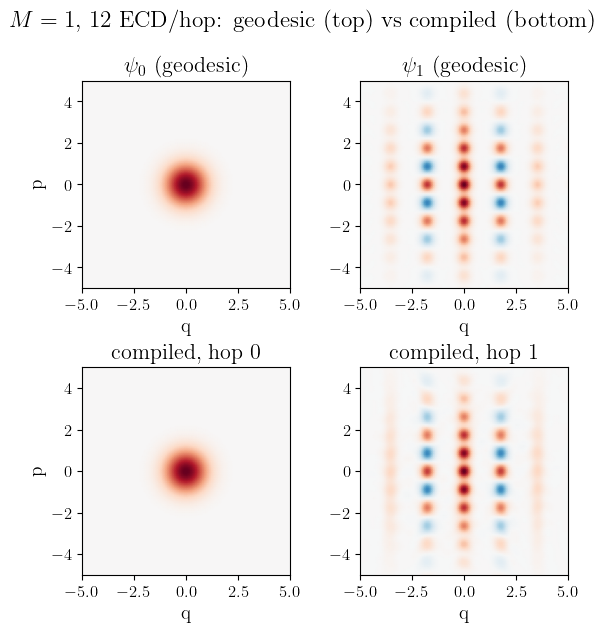

In [20]:
# Best run among the ones narrow enough to plot as a strip.
_candidates = [m for m in ms if m <= 6] or list(ms)
best_m = int(min(_candidates, key=lambda m: 1 - sweep[m].composed_fidelity))
show = sweep[best_m]
n_cols = show.n_segments + 1

fig, axes = plt.subplots(2, n_cols, figsize=(3.0 * n_cols, 6.4))
axes = np.atleast_2d(axes)

for k in range(n_cols):
    plot_wigner(
        to_qarray(show.waypoints[k]),
        x_bound=X_BOUND,
        y_bound=Y_BOUND,
        ax=axes[0, k],
        title=rf"$\psi_{{{k}}}$ (geodesic)",
        grid_points=120,
        add_colorbar=False,
    )
    block = show.joint_states[k]  # (2, n_fock)
    rho_cav = block.T @ block.conj()  # trace out the qubit
    plot_wigner(
        to_qarray(rho_cav),
        x_bound=X_BOUND,
        y_bound=Y_BOUND,
        ax=axes[1, k],
        title=rf"compiled, hop {k}",
        grid_points=120,
        add_colorbar=False,
    )
    if k:
        axes[0, k].set_ylabel("")
        axes[1, k].set_ylabel("")

fig.suptitle(
    rf"$M = {best_m}$, {show.n_gates} ECD/hop: geodesic (top) vs compiled (bottom)"
)
fig.tight_layout()
plt.show()

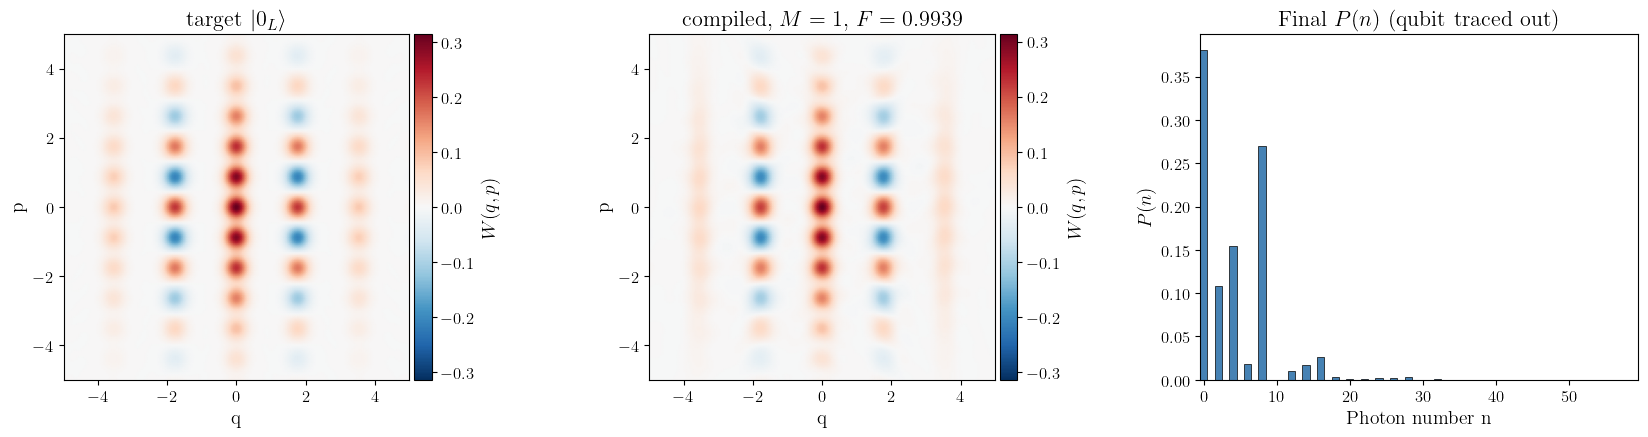

truncation check: population in top 8 Fock levels = 5.37e-05


In [21]:
final_block = show.joint_states[-1]
rho_final = final_block.T @ final_block.conj()

fig, (ax_t, ax_a, ax_n) = plt.subplots(1, 3, figsize=(17, 4.6))

plot_wigner(
    to_qarray(psi_f),
    x_bound=X_BOUND,
    y_bound=Y_BOUND,
    ax=ax_t,
    title=rf"target $\ket{{{target_label}}}$",
)
plot_wigner(
    to_qarray(rho_final),
    x_bound=X_BOUND,
    y_bound=Y_BOUND,
    ax=ax_a,
    title=rf"compiled, $M = {best_m}$, $F = {show.composed_fidelity:.4f}$",
)
plot_photon_number(to_qarray(rho_final), ax=ax_n, title="Final $P(n)$ (qubit traced out)")

fig.tight_layout()
plt.show()

print(f"truncation check: population in top 8 Fock levels = "
      f"{float(np.sum(np.real(np.diag(rho_final))[-8:])):.2e}")

## Reading the result

What to take from the sweep, and what not to:

- **Uniform hops, uniform cost.** Equal-time splits of the brachistochrone are
  equal-arc-length splits, verified above. If per-hop infidelities at fixed depth come
  out uniform, the ECD gate set is roughly isotropic along this particular path; if
  they do not, the spread localizes where the phase-space motion is expensive, which
  for the ECD set means where large $|\beta|$ is needed.
- **The composed fidelity is the only number that counts.** Per-hop fidelities near
  unity say nothing on their own — they compose multiplicatively at best, and the
  residual $\ket{e}$ population is a genuine loss channel for an open-loop circuit,
  not a bookkeeping artifact. The heralded number is strictly better and strictly less
  useful unless mid-circuit measurement is actually in the plan.
- **Any advantage at large $M$ is an optimization effect, not a physics one.** A
  partitioned circuit is not more expressive than a monolithic one of the same ECD
  count — it is *less* free in its path and only slightly more free in its rotations
  (each junction contributes two adjacent equatorial rotations where the monolithic
  ansatz has one, so the composite is not exactly an instance of the standard ansatz).
  If waypoints help, they help by convexifying the landscape and providing warm starts.
- **Deep circuits at small $M$ may be under-converged.** If $M = 1$ stalls with
  gradient norms well above zero, the fidelity ceiling has not been found; raise
  `n_adam_iters`, add seeds, or anneal the depth before concluding the monolithic
  approach is worse.

## Next: the pulse level

The natural continuation, keeping the same waypoint structure:

1. Compile each hop's ECD parameters into a pulse with the two-step
   Eickbusch approach, and remember that the displaced frame does not close —
   the trailing $D(\alpha(T))$ correction per segment is what takes single-ECD
   overlap from ~0.9995 to ~0.999999, and $M$ uncorrected segments compound
   that error $M$ times.
2. Re-simulate the chained pulses under the full dispersive Hamiltonian, so
   finite pulse duration, Kerr, and the virtual-Z frame updates ($F \leftarrow
   -F + \theta'$ at each junction) all enter. Segment boundaries are where
   frame bookkeeping errors hide.
3. Compare the total *physical* duration of the compiled pulse sequence against
   $T = \Omega_B / \omega$ with $\omega$ set by the actual drive bound rather
   than 1. That is the comparison the brachistochrone was constructed to
   support, and the ratio is the real figure of merit — not the gate count.